#### SE TENÍA ESTE WORKFLOW SECUENCIAL:

In [1]:
from typing import TypedDict

class State(TypedDict):
    customer_name: str
    my_age: int

def node_1(state: State):  
    return state

def node_2(state: State):  
    return state

def node_3(state: State):  
    return state

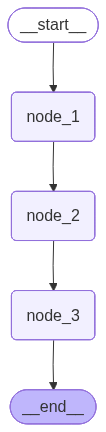

In [3]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(State)
builder.add_edge(START, "node_1")
builder.add_sequence([node_1, node_2, node_3])
agent = builder.compile()
display(Image(agent.get_graph().draw_mermaid_png()))

#### **AHORA CON ROUTING**: Antes los nodos solo se usaban para ejecutar alguna acción/función y actualizar el estado, pero ahora también pueden tener una función de routing que determine a qué nodo ir después dependiendo del estado actual. Esto permite crear flujos más dinámicos y adaptativos. -> Se conocen como Route Edges

In [6]:
import random
from typing import Literal #Esto es para indicar que el output solo puede ser uno de los valores indicados

def route_edge(state: State) -> Literal["node_2", "node_3"]:
    if random.random() < 0.5:
        return "node_2"
    return "node_3"

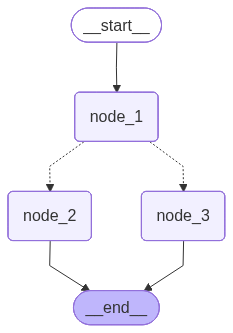

In [8]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
# Se crean los nodos
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Se hacen los edges
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", route_edge)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

agent = builder.compile()
display(Image(agent.get_graph().draw_mermaid_png()))

No es necesario siempre tener un nodo 1 para hace rel routing, también se pueden hacer rutas condicionales desde el nodo de inicio (START) o entre cualquier otro nodo. En este ejemplo se hace desde el nodo 1, pero podría hacerse desde START o desde el nodo 2 por ejemplo:

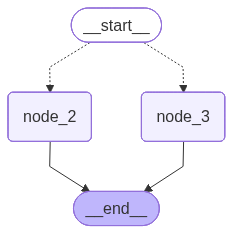

In [11]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
# Se crean los nodos
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Se hacen los edges
builder.add_conditional_edges(START, route_edge)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

agent = builder.compile()
display(Image(agent.get_graph().draw_mermaid_png()))

#### TAREA DE CREAR UN WORKFLOW COMPLEJO CON ROUTING

In [13]:
from typing import TypedDict

class State(TypedDict):
    patient_name: str
    age: int
    type_of_appointment: str

def extractor(state: State):  
    return state

def certificados(state: State):  
    return state

def agendamiento(state: State):  
    return state

def afiliaciones(state: State):  
    return state

In [16]:
from typing import Literal #Esto es para indicar que el output solo puede ser uno de los valores indicados

def route_edge(state: State) -> Literal["certificados", "agendamiento", "afiliaciones"]:
    if state["type_of_appointment"] == "certificados":
        return "certificados"
    elif state["type_of_appointment"] == "agendamiento":
        return "agendamiento"
    elif state["type_of_appointment"] == "afiliaciones":
        return "afiliaciones"

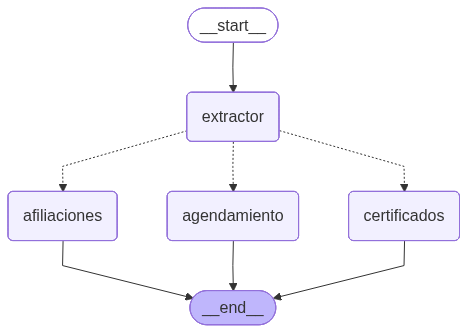

In [17]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
# Se crean los nodos
builder.add_node("extractor", extractor)
builder.add_node("certificados", certificados)
builder.add_node("agendamiento", agendamiento)
builder.add_node("afiliaciones", afiliaciones)

# Se hacen los edges
builder.add_edge(START, "extractor")
builder.add_conditional_edges("extractor", route_edge)
builder.add_edge("certificados", END)
builder.add_edge("agendamiento", END)
builder.add_edge("afiliaciones", END)

agent = builder.compile()
display(Image(agent.get_graph().draw_mermaid_png()))